# E-commerce investigative Data Analysis

## 1. Business understanding 

### 1.1 Why this investigation?

Modern e-commerce companies generate millions of transactions every day. While dashboards can report sales, orders, and revenue, they often fail to explain why certain business problems occur. Questions such as why some customers leave poor reviews, why deliveries are delayed, or why certain sellers consistently outperform others cannot be answered by descriptive reports alone.

This project approaches the dataset as a business investigation rather than a traditional exploratory data analysis exercise. The objective is to identify meaningful business problems, formulate hypotheses, validate them using data, uncover root causes, and provide practical recommendations that support better business decisions.


### 1.2 Business Context

Olist is a Brazilian e-commerce marketplace where customers can purchase products from thousands of independent sellers through a single platform. Every order placed on the platform generates business data, from payment and delivery to customer reviews.

This dataset brings those records together, making it possible to understand how different parts of the business are connected. Instead of analyzing each table separately, this investigation will connect the datasets to identify patterns, understand business performance, and answer real business questions.

### 1.3 Investigation Goals

The goal of this investigation is to understand how different parts of the Olist marketplace contribute to overall business performance. By connecting information from customers, sellers, products, orders, payments, deliveries, and reviews, this analysis will focus on identifying meaningful patterns that can help explain business outcomes.

Throughout this project, each analysis will be driven by a business question rather than curiosity alone. The results will be used to test hypotheses, understand possible reasons behind business trends, and provide practical recommendations based on the available data.

## 2. Datasets Used

The analysis uses nine interconnected datasets from the Olist e-commerce database, covering customers, orders, products, sellers, payments, reviews, geographic information, and product categories.

| Dataset | Purpose |
|---|---|
| Customers | Contains customer identifiers and location details |
| Orders | Contains order status and purchase, approval, delivery, and estimated delivery dates |
| Order Items | Connects orders with products and sellers, including price and freight value |
| Order Payments | Contains payment type, instalments, and payment value |
| Order Reviews | Contains customer review scores and review information |
| Products | Contains product categories, dimensions, weight, and other product attributes |
| Sellers | Contains seller identifiers and location details |
| Geolocation | Contains ZIP code, latitude, longitude, city, and state information |
| Product Category Translation | Translates Portuguese product category names into English |

## 3. Data Schema

The datasets follow a relational structure, with common identifiers connecting customer, order, product, seller, payment, and review information.

```
Customers
    │
    │ customer_id
    ▼
Orders
    │
    ├── order_id ──────► Order Payments
    │
    ├── order_id ──────► Order Reviews
    │
    └── order_id
           │
           ▼
       Order Items
        │       │
        │       │
 product_id   seller_id
        │       │
        ▼       ▼
    Products   Sellers
        │
        │ product_category_name
        ▼
Product Category Translation


Customers ── ZIP code prefix ──┐
                               ├──► Geolocation
Sellers ─── ZIP code prefix ───┘
```

### 4. Data Loading

In [41]:
import pandas as pd

In [42]:
customers = pd.read_csv("data/olist_customers_dataset.csv")
geolocation = pd.read_csv("data/olist_geolocation_dataset.csv")
order_items = pd.read_csv("data/olist_order_items_dataset.csv")
order_payments = pd.read_csv("data/olist_order_payments_dataset.csv")
order_reviews = pd.read_csv("data/olist_order_reviews_dataset.csv")
orders = pd.read_csv("data/olist_orders_dataset.csv")
products = pd.read_csv("data/olist_products_dataset.csv")
sellers = pd.read_csv("data/olist_sellers_dataset.csv")
category_translation = pd.read_csv("data/product_category_name_translation.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


### 5. Dataset overview
The following table provides an overview of each dataset, including the number of rows, columns, missing values, and duplicate records before the analysis begins.

In [43]:
datasets = {
    "Customers": customers,
    "Orders": orders,
    "Order Items": order_items,
    "Payments": order_payments,
    "Reviews": order_reviews,
    "Products": products,
    "Sellers": sellers,
    "Geolocation": geolocation,
    "Category Translation": category_translation
}

overview = pd.DataFrame({
    "Dataset": datasets.keys(),
    "Rows": [df.shape[0] for df in datasets.values()],
    "Columns": [df.shape[1] for df in datasets.values()],
    "Missing Values": [df.isnull().sum().sum() for df in datasets.values()],
    "Duplicate Rows": [df.duplicated().sum() for df in datasets.values()]
})

overview

,Dataset,Rows,Columns,Missing Values,Duplicate Rows
0,Customers,99441,5,0,0
1,Orders,99441,8,4908,0
2,Order Items,112650,7,0,0
3,Payments,103886,5,0,0
4,Reviews,99224,7,145903,0
5,Products,32951,9,2448,0
6,Sellers,3095,4,0,0
7,Geolocation,1000163,5,0,261831
8,Category Translation,71,2,0,0


### 0bservation

The initial dataset overview shows that the project consists of nine related datasets with varying sizes and structures. While most datasets do not contain duplicate records, missing values are present in the Orders, Reviews, and Products datasets, indicating that data cleaning will be required before analysis. 

The Geolocation dataset contains duplicate rows, which will also be examined during the preprocessing stage.

## 6. Data Cleaning

### 6.1 Business objective

The objective of this phase is to assess the quality of the datasets and prepare them for analysis. This involves identifying missing values, duplicate records, and data inconsistencies to ensure that the merged dataset is accurate, reliable, and suitable for business decision-making.

In [44]:
cleaning_summary = pd.DataFrame({
    "Dataset": datasets.keys(),
    "Missing Values": [df.isnull().sum().sum() for df in datasets.values()],
    "Duplicate Rows": [df.duplicated().sum() for df in datasets.values()]
})

cleaning_summary

,Dataset,Missing Values,Duplicate Rows
0,Customers,0,0
1,Orders,4908,0
2,Order Items,0,0
3,Payments,0,0
4,Reviews,145903,0
5,Products,2448,0
6,Sellers,0,0
7,Geolocation,0,261831
8,Category Translation,0,0


### Cleaning Summary

The cleaning summary indicates that most datasets are free from missing values and duplicate records. However, the Orders, Reviews, and Products datasets contain missing values that require further investigation before merging. 

The Geolocation dataset contains a significant number of duplicate rows, which will be evaluated to determine whether they represent valid repeated locations or redundant records.

6.2

In [45]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Most columns in the Orders dataset are complete, with missing values found only in the order_approved_at, order_delivered_carrier_date, and order_delivered_customer_date columns. Since these fields are related to the order fulfillment process, the missing values are likely to represent valid business scenarios, such as cancelled or undelivered orders, rather than data quality issues.

No immediate cleaning action is required because the missing values are consistent with the order lifecycle.

6.3

In [46]:
orders[orders["order_delivered_customer_date"].isnull()]["order_status"].value_counts()

order_status
shipped        1107
canceled        619
unavailable     609
invoiced        314
processing      301
delivered         8
created           5
approved          2
Name: count, dtype: int64

Customer delivery dates are missing mainly for orders with statuses such as shipped, cancelled, unavailable, processing, and invoiced. Since these orders were not successfully completed, the absence of delivery dates is generally expected as part of the order lifecycle rather than a data quality issue.

A small number of records marked as delivered still contain missing delivery dates. These records will be retained because there is not enough evidence to justify their removal.

6.4

In [47]:
order_reviews.isnull().sum()

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

Missing values are concentrated only in the review_comment_title and review_comment_message columns, while all other review-related fields are complete.

Since customers can submit a rating without necessarily providing a review title or detailed comment, these missing values are likely due to optional user input rather than poor data quality. These fields can safely remain unchanged because textual comments are not mandatory.

6.5

In [48]:
products.isnull().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

 missing values are primarily found in the product category and descriptive attributes, affecting 610 records. This suggests that some products were listed without complete information, possibly due to incomplete seller submissions or unavailable product details.

Only two records contain missing physical dimensions (weight, length, height, and width), indicating isolated data entry issues rather than a widespread quality problem. No immediate cleaning action is required.

6.6

In [49]:
products[products["product_category_name"].isnull()]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
105,a41e356c76fab66334f36de622ecbd3a,NaN,NaN,NaN,NaN,650.0,17.0,14.0,12.0
128,d8dee61c2034d6d075997acef1870e9b,NaN,NaN,NaN,NaN,300.0,16.0,7.0,20.0
145,56139431d72cd51f19eb9f7dae4d1617,NaN,NaN,NaN,NaN,200.0,20.0,20.0,20.0
154,46b48281eb6d663ced748f324108c733,NaN,NaN,NaN,NaN,18500.0,41.0,30.0,41.0
197,5fb61f482620cb672f5e586bb132eae9,NaN,NaN,NaN,NaN,300.0,35.0,7.0,12.0
...,...,...,...,...,...,...,...,...,...
32515,b0a0c5dd78e644373b199380612c350a,NaN,NaN,NaN,NaN,1800.0,30.0,20.0,70.0
32589,10dbe0fbaa2c505123c17fdc34a63c56,NaN,NaN,NaN,NaN,800.0,30.0,10.0,23.0
32616,bd2ada37b58ae94cc838b9c0569fecd8,NaN,NaN,NaN,NaN,200.0,21.0,8.0,16.0
32772,fa51e914046aab32764c41356b9d4ea4,NaN,NaN,NaN,NaN,1300.0,45.0,16.0,45.0




Inspecting the missing records confirms that the same group of products lacks category and descriptive information, while the physical attributes such as weight and dimensions are available. This indicates that the products were likely created with essential logistics information but without complete descriptive details. 

Since the product identifiers are present, these records may still be associated with actual customer orders. Therefore, they will be retained for now, and their business impact will be evaluated after merging the datasets before making any cleaning decision.

6.7

In [50]:
geolocation[geolocation.duplicated()].head(10)

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
15,1046,-23.546081,-46.644820,sao paulo,SP
44,1046,-23.546081,-46.644820,sao paulo,SP
65,1046,-23.546081,-46.644820,sao paulo,SP
66,1009,-23.546935,-46.636588,sao paulo,SP
67,1046,-23.546081,-46.644820,sao paulo,SP
72,1046,-23.545320,-46.644069,sao paulo,SP
79,1050,-23.549854,-46.643139,sao paulo,SP
80,1032,-23.540775,-46.635515,sao paulo,SP
82,1046,-23.546081,-46.644820,sao paulo,SP
86,1048,-23.547449,-46.640169,são paulo,SP




The duplicate records show that several geolocation entries are repeated with the same ZIP code, city, state, and geographic coordinates. However, the initial inspection also suggests that some records share the same ZIP code while having slightly different latitude and longitude values. 

Therefore, further investigation is required to distinguish true duplicate records from valid geolocation variations before removing any data.

6.8

In [51]:
geolocation.groupby("geolocation_zip_code_prefix")[["geolocation_lat", "geolocation_lng"]].nunique().head(10)

,geolocation_lat,geolocation_lng
geolocation_zip_code_prefix,,
1001,10,10
1002,6,6
1003,10,10
1004,14,14
1005,11,11
1006,7,7
1007,15,15
1008,12,12
1009,7,7




The analysis shows that a single ZIP code can have multiple unique latitude and longitude values. This indicates that different locations may exist within the same ZIP code area. Therefore, duplicate records cannot be removed based solely on the ZIP code. 

Only exact duplicate records will be removed to eliminate redundant entries while preserving valid geographic information.

6.9

In [52]:
geolocation = geolocation.drop_duplicates()

In [53]:
geolocation.shape

(738332, 5)

### 6.10 Final Cleaning Outcome

Data quality has been improved while preserving meaningful business information. Missing values in the Orders, Reviews, and Products datasets were retained wherever they represented valid business scenarios instead of data quality issues. The Geolocation dataset was carefully reviewed, and only exact duplicate records were removed after confirming that multiple geographic coordinates could legitimately exist within the same ZIP code.

With these cleaning steps completed, the datasets are now consistent and ready for integration and further business analysis.

# 7. Dataset Integration (Data Merging)

### 7.1 Business Objective

The Olist data is stored across multiple related tables, where each dataset represents a different part of the business process. To perform end-to-end business analysis, these datasets must be integrated into a single analytical dataset. This allows customer, order, product, payment, seller, and review information to be analyzed together for meaningful business insights.

### 7.2 Merge Strategy

The **Orders** dataset will be used as the base table because it represents the central business transaction and connects customers, order items, payments, and reviews. Additional datasets such as products, sellers, and product category translations will be merged through the Order Items dataset to build a complete analytical dataset for business analysis.

In [54]:
# Merge customer information
merged_df = orders.merge(
    customers,
    on="customer_id",
    how="left"
)

# Merge ordered products
merged_df = merged_df.merge(
    order_items,
    on="order_id",
    how="left"
)

# Merge product details
merged_df = merged_df.merge(
    products,
    on="product_id",
    how="left"
)

# Merge seller information
merged_df = merged_df.merge(
    sellers,
    on="seller_id",
    how="left"
)

# Merge payment information
merged_df = merged_df.merge(
    order_payments,
    on="order_id",
    how="left"
)

# Merge customer reviews
merged_df = merged_df.merge(
    order_reviews,
    on="order_id",
    how="left"
)

# Merge English product category names
merged_df = merged_df.merge(
    category_translation,
    on="product_category_name",
    how="left"
)

In [55]:
merged_df.shape

(119143, 40)

### Observation

All relevant business datasets were successfully integrated into a single analytical dataset using their respective keys. The increase in the number of rows is expected because a single order can contain multiple products, resulting in multiple order item records. The final analytical dataset now combines customer, order, product, seller, payment, review, and English product category information, making it ready for business analysis and KPI evaluation.

# 8. Exploratory Data Analysis (EDA)

### 8.1 Analysis Objective

After integrating all business datasets into a single analytical dataset, the next objective is to explore the data and identify meaningful business insights. This phase focuses on evaluating key business metrics, customer behavior, product performance, seller performance, payment trends, and delivery performance to support data-driven decision-making.

### 8.2 KPI Overview

In [56]:
kpi = {
    "Total Orders": merged_df["order_id"].nunique(),
    "Total Customers": merged_df["customer_unique_id"].nunique(),
    "Total Revenue": merged_df["payment_value"].sum(),
    "Total Products Sold": merged_df["product_id"].nunique(),
    "Total Sellers": merged_df["seller_id"].nunique(),
    "Average Review Score": merged_df["review_score"].mean()
}

kpi_table = pd.DataFrame(kpi.items(), columns=["KPI", "Value"])

kpi_table["Value"] = [
    f"{value:,.2f}" if kpi_name in ["Total Revenue", "Average Review Score"]
    else f"{value:,.0f}"
    for kpi_name, value in kpi.items()
]

kpi_table

,KPI,Value
0,Total Orders,"99,441"
1,Total Customers,"96,096"
2,Total Revenue,"20,579,664.01"
3,Total Products Sold,"32,951"
4,Total Sellers,"3,095"
5,Average Review Score,4.02


### 8.3 KPI Insights

The KPI overview provides a high-level snapshot of the business. The company has processed a large number of orders, served thousands of unique customers, generated significant revenue, and maintained an average customer review score of approximately 4 out of 5. These metrics establish the baseline for the detailed business analysis that follows.

## 9. Transition to Business Analysis

The KPI overview provides a snapshot of the overall business performance. However, summary metrics alone cannot explain the factors driving revenue, customer satisfaction, and operational performance. The following business questions investigate these areas to identify actionable insights and support strategic decision-making.

### 9.1 Which Product Categories Generate the Highest Revenue?

#### Business Context

Product categories contribute differently to the company's revenue. Identifying the highest revenue-generating categories helps management prioritize marketing investments, inventory planning, and business growth strategies.

In [57]:
revenue_by_category = (
    merged_df.groupby("product_category_name_english")["payment_value"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

revenue_by_category.rename("Total Revenue").reset_index().rename(
    columns={"product_category_name_english": "Product Category"}
)

,Product Category,Total Revenue
0,bed_bath_table,1743998.80
1,health_beauty,1662963.59
2,computers_accessories,1599481.06
3,furniture_decor,1443963.61
4,watches_gifts,1430553.48
5,sports_leisure,1400223.07
6,housewares,1097900.09
7,auto,855095.68
8,garden_tools,840721.59
9,cool_stuff,781933.97


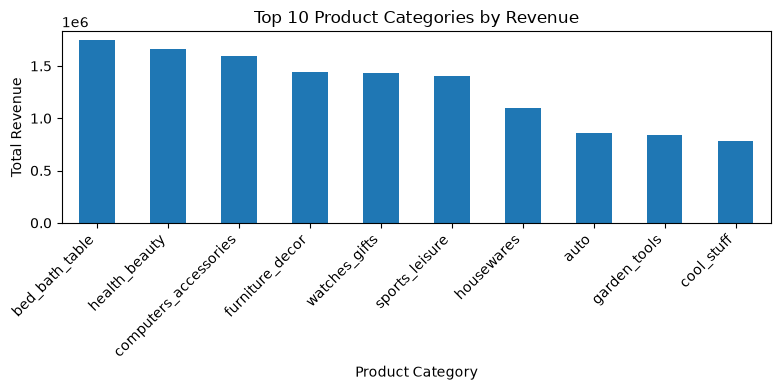

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

revenue_by_category.plot(kind="bar")

plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

### Observation

Bed Bath Table emerged as the highest revenue-generating product category with approximately 1.74 million in revenue, followed by Health Beauty (1.66 million) and Computers Accessories (1.60 million). The remaining top categories generated comparatively lower revenue, indicating that a relatively small number of product categories contribute a significant share of the marketplace's overall revenue.

### Business Recommendation

Maintaining strong product availability, effective inventory planning, and consistent marketing efforts for the highest-revenue categories will help sustain overall revenue performance. At the same time, lower-revenue categories should be evaluated to identify opportunities for improving pricing, product assortment, and promotional strategies, enabling them to contribute more effectively to marketplace revenue.

### 9.2 Which Product Categories Receive the Highest Number of Orders?

### Business Context

Order volume reflects customer demand across different product categories. Examining the categories with the highest number of orders helps identify where customer interest is strongest, enabling better inventory planning, product availability, and marketing decisions to support marketplace performance.

In [59]:
orders_by_category = (
    merged_df.groupby("product_category_name_english")["order_id"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

orders_by_category.rename("Total Orders").reset_index().rename(
    columns={"product_category_name_english": "Product Category"}
)

,Product Category,Total Orders
0,bed_bath_table,9417
1,health_beauty,8836
2,sports_leisure,7720
3,computers_accessories,6689
4,furniture_decor,6449
5,housewares,5884
6,watches_gifts,5624
7,telephony,4199
8,auto,3897
9,toys,3886


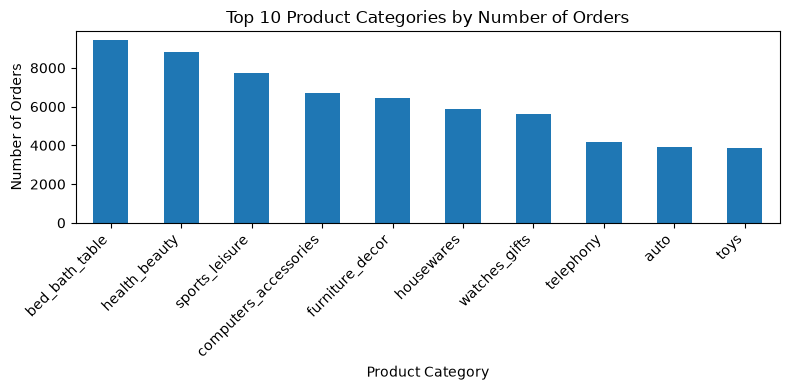

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

orders_by_category.plot(kind="bar")

plt.title("Top 10 Product Categories by Number of Orders")
plt.xlabel("Product Category")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

### Observation

The analysis indicates that Bed Bath Table received the highest number of orders, followed by Health Beauty and Sports Leisure. While these categories attract the largest share of customer purchases, their order ranking differs slightly from the revenue ranking, suggesting that higher order volume does not always translate into the highest revenue.


### Business Recommendation

To maximize sales opportunities, the business should ensure consistent product availability in these high-demand categories and monitor stock levels closely. Categories with strong order volume but lower revenue can be optimized by encouraging larger basket sizes through bundles, complementary products, and personalized product recommendations.

### 9.3 How Has Monthly Sales Changed Over Time?

### Business Context

Understanding monthly sales trends helps the company identify business growth, seasonal demand, and periods of lower performance. This analysis enables management to plan inventory, marketing campaigns, and operational resources more effectively throughout the year.

In [61]:
merged_df["order_purchase_timestamp"] = pd.to_datetime(
    merged_df["order_purchase_timestamp"]
)

monthly_sales = (
    merged_df.groupby(
        merged_df["order_purchase_timestamp"].dt.to_period("M")
    )["payment_value"]
    .sum()
)

monthly_sales.rename("Total Revenue").reset_index().rename(
    columns={"order_purchase_timestamp": "Month"}
)

,Month,Total Revenue
0,2016-09,388.47
1,2016-10,76559.05
2,2016-12,19.62
3,2017-01,190806.27
4,2017-02,351848.13
5,2017-03,547769.84
6,2017-04,512126.52
7,2017-05,737425.31
8,2017-06,613777.41
9,2017-07,749242.84


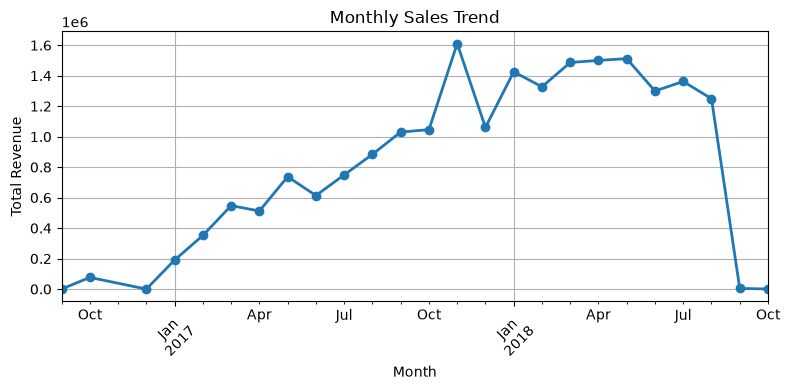

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

monthly_sales.plot(
    kind="line",
    marker="o",
    linewidth=2
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")

plt.xticks(rotation=45)

plt.grid(True)

plt.tight_layout()
plt.show()

### Observation

The monthly sales trend shows a steady increase in revenue from early 2017 through the first half of 2018, indicating positive business growth and increasing customer demand.

A few months show slight fluctuations, which may be influenced by seasonal buying patterns or promotional activities. The sharp decline in the final months of 2018 is likely due to incomplete data available in the dataset rather than an actual drop in business performance.

### Business Recommendation

The company should analyze the factors that contributed to the strong sales performance during peak months and apply similar marketing strategies in future campaigns.

Regular monitoring of monthly sales trends can also help identify seasonal demand, improve inventory planning, and support better business decision-making.

### 9.4 Which States Generate the Highest Revenue?
### Business Context
Different states contribute differently to the company's overall revenue. Identifying the states that generate the highest revenue helps the business allocate marketing budgets, optimize logistics, improve inventory distribution, and identify regions with strong customer demand. This analysis also supports regional business expansion and strategic decision-making.

In [63]:
revenue_by_state = (
    merged_df.groupby("customer_state")["payment_value"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

revenue_by_state.rename("Total Revenue").reset_index().rename(
    columns={"customer_state": "Customer State"}
)

,Customer State,Total Revenue
0,SP,7726078.35
1,RJ,2795615.67
2,MG,2351221.09
3,RS,1160175.66
4,PR,1079795.49
5,BA,805070.98
6,SC,801276.45
7,GO,520481.65
8,DF,438095.32
9,ES,408611.64


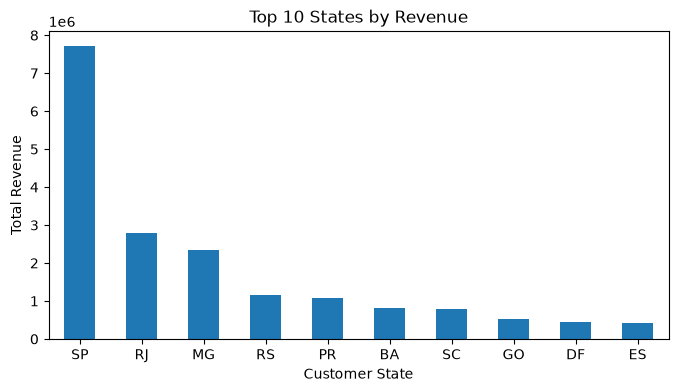

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

revenue_by_state.plot(
    kind="bar",
    color="tab:blue"
)

plt.title("Top 10 States by Revenue")
plt.xlabel("Customer State")
plt.ylabel("Total Revenue")
plt.xticks(rotation=0)

plt.show()

### Observation
The revenue analysis shows that São Paulo (SP) is the highest revenue-generating state, followed by Rio de Janeiro (RJ) and Minas Gerais (MG). These states contribute a significant share of the company's total revenue, indicating a strong customer base and high purchasing activity. In contrast, states such as GO, DF, and ES generate comparatively lower revenue.

### Business Recommendation
Focusing on high-performing states like SP, RJ, and MG through stronger marketing campaigns, sufficient inventory, and improved customer retention can help maintain strong revenue performance. For lower-performing states, the business should analyze customer behavior and introduce targeted promotions, localized marketing strategies, and improved logistics to increase revenue.

### 9.5 Which Sellers Generate The Highest Revenue?
### Business context

Seller performance has a direct impact on marketplace revenue because not every seller contributes equally to total sales. Analyzing the highest-revenue sellers helps identify successful business partners and uncover practices that can improve overall marketplace performance.

In [65]:
revenue_by_seller = (
    merged_df.groupby("seller_id")["payment_value"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

revenue_by_seller.rename("Total Revenue").reset_index().rename(
    columns={"seller_id": "Seller ID"}
)

,Seller ID,Total Revenue
0,7c67e1448b00f6e969d365cea6b010ab,512645.19
1,1025f0e2d44d7041d6cf58b6550e0bfa,312456.49
2,4a3ca9315b744ce9f8e9374361493884,306138.80
3,1f50f920176fa81dab994f9023523100,291918.98
4,53243585a1d6dc2643021fd1853d8905,284903.08
5,da8622b14eb17ae2831f4ac5b9dab84a,276578.63
6,4869f7a5dfa277a7dca6462dcf3b52b2,264166.12
7,955fee9216a65b617aa5c0531780ce60,236414.48
8,fa1c13f2614d7b5c4749cbc52fecda94,206513.23
9,7e93a43ef30c4f03f38b393420bc753a,185134.21


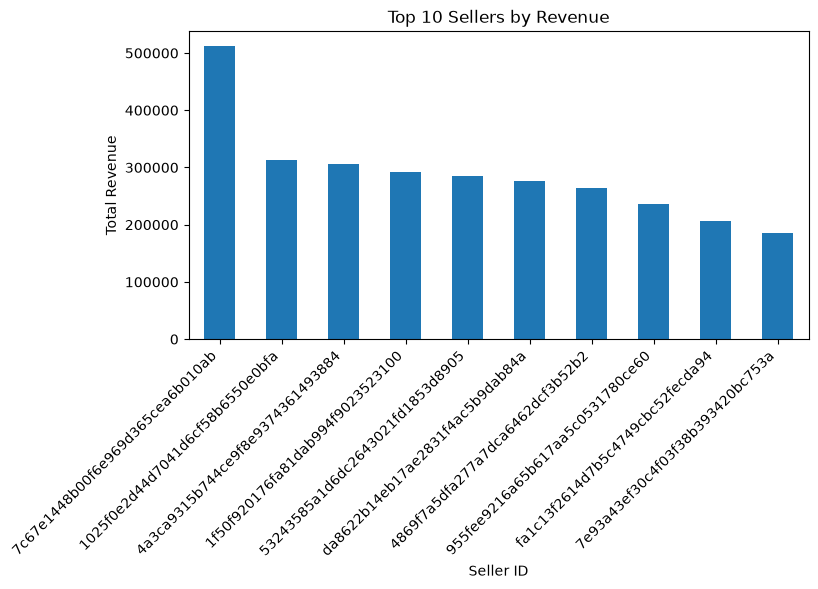

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

revenue_by_seller.plot(
    kind="bar",
    color="tab:blue"
)

plt.title("Top 10 Sellers by Revenue")
plt.xlabel("Seller ID")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45, ha="right")

plt.show()

### Observation
The findings reveal that revenue is heavily concentrated among a small group of sellers. The highest-performing seller generated more than 512,000 in total revenue, while the remaining top sellers recorded noticeably lower revenue figures. This pattern indicates that a handful of high-performing sellers play a crucial role in sustaining the marketplace's overall revenue.

### Business Recommendation
Strengthening relationships with the marketplace's top-performing sellers through dedicated support, exclusive incentives, and long-term partnerships can help sustain revenue growth. In addition, evaluating the strategies used by these successful sellers and sharing best practices across the seller network may improve overall seller performance and create a more balanced contribution to marketplace revenue.

### 9.6 How Does Customer Review Score Affect Sales?
### Business Context
Customer reviews play an important role in influencing purchasing decisions and overall business performance. Analyzing the relationship between review scores and sales revenue helps the company understand whether better customer satisfaction is associated with higher revenue. These insights can support improvements in product quality, customer service, and long-term business growth.

In [67]:
review_sales = (
    merged_df.groupby("review_score", as_index=False)
    .agg(
        Total_Revenue=("payment_value", "sum"),
        Total_Orders=("order_id", "count"),
        Average_Order_Value=("payment_value", "mean")
    )
    .sort_values("review_score")
)

review_sales

,review_score,Total_Revenue,Total_Orders,Average_Order_Value
0,1.0,3572902.46,15428,231.630629
1,2.0,796261.23,4162,191.316970
2,3.0,1660610.82,9894,167.840188
3,4.0,3648468.83,22319,163.469189
4,5.0,10666458.37,66343,160.777450


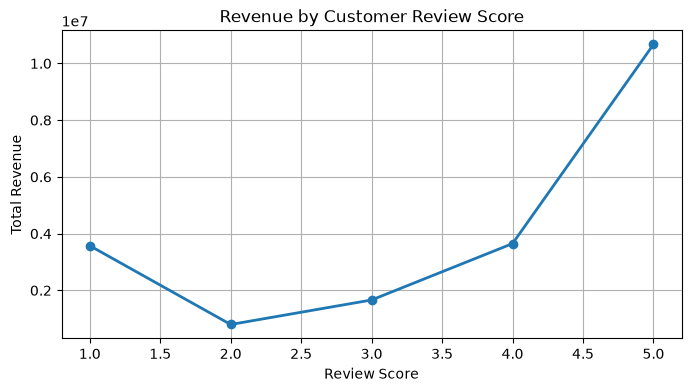

In [68]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

plt.plot(
    review_sales["review_score"],
    review_sales["Total_Revenue"],
    marker="o",
    linewidth=2
)

plt.title("Revenue by Customer Review Score")
plt.xlabel("Review Score")
plt.ylabel("Total Revenue")

plt.grid(True)

plt.show()

### Observation
Orders with a 5-star review generated the highest revenue (over 10.6 million) and also recorded the largest number of orders. In contrast, 2-star reviews contributed the lowest revenue, while revenue generally increased as review scores improved. This trend suggests that higher customer satisfaction is closely associated with stronger sales performance and greater marketplace revenue.

### Business Recommendation
Maintaining consistently high customer satisfaction through better product quality, timely deliveries, and responsive customer support can help encourage more positive reviews and sustain revenue growth. Regularly analyzing customer feedback and addressing recurring issues can further improve the shopping experience, strengthen customer loyalty, and increase repeat purchases over time.

### 9.7 Which Payment Methods Are Most Preferred by Customers?
### Business Context

Payment methods influence both the customer checkout experience and overall transaction efficiency. Examining the most preferred payment methods provides valuable insights into customer purchasing behavior and helps businesses optimize payment options, improve convenience, and support overall sales performance.

In [69]:
payment_analysis = (
    merged_df.pivot_table(
        index="payment_type",
        values="payment_value",
        aggfunc=["count", "sum", "mean"]
    )
)

payment_analysis.columns = [
    "Total_Orders",
    "Total_Revenue",
    "Average_Payment"
]

payment_analysis = (
    payment_analysis
    .sort_values("Total_Orders", ascending=False)
    .reset_index()
)

payment_analysis

,payment_type,Total_Orders,Total_Revenue,Average_Payment
0,credit_card,87776,15775450.54,179.723963
1,boleto,23190,4110920.74,177.271270
2,voucher,6465,435917.84,67.427353
3,debit_card,1706,257374.89,150.864531
4,not_defined,3,0.00,0.000000


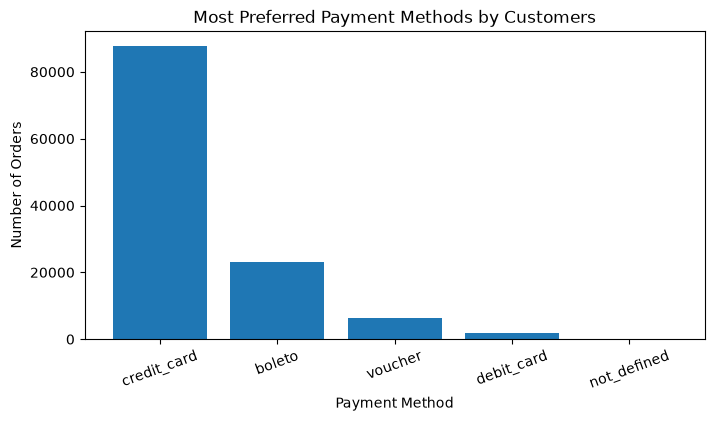

In [70]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

plt.bar(
    payment_analysis["payment_type"],
    payment_analysis["Total_Orders"]
)

plt.title("Most Preferred Payment Methods by Customers")
plt.xlabel("Payment Method")
plt.ylabel("Number of Orders")

plt.xticks(rotation=20)

plt.show()

### Observation
Credit cards dominate customer payment behavior, accounting for 87,776 orders and generating approximately 15.78 million in total revenue. Boleto ranks as the second most preferred payment method with 23,190 orders, while voucher and debit card are used by a much smaller portion of customers. This pattern suggests that customers strongly prefer payment methods that are convenient, widely accepted, and familiar during checkout.

### Business Recommendation
Expanding secure and seamless credit card payment features can help maintain a smooth checkout experience for the majority of customers. Meanwhile, increasing awareness of alternative payment options such as boleto and debit card through targeted offers or promotional campaigns may encourage broader payment adoption, reduce dependence on a single payment method, and provide customers with greater flexibility during purchases.

### 9.8 Customer Satisfaction Across Product Categories
### Business Context
Customer satisfaction plays a crucial role in long-term business growth, as positive customer experiences often lead to repeat purchases, stronger brand loyalty, and positive word-of-mouth. Although some product categories may generate high sales, they do not always deliver the highest customer satisfaction. Examining customer ratings across different product categories helps identify products that consistently meet or exceed customer expectations, allowing the business to preserve its strengths while addressing areas that require improvement

In [71]:
# Merge orders, order items, products, translation table, and reviews

customer_satisfaction = (
    orders
    .merge(order_items, on="order_id", how="inner")
    .merge(products, on="product_id", how="inner")
    .merge(category_translation, on="product_category_name", how="left")
    .merge(order_reviews, on="order_id", how="inner")
)

# Calculate average review score by product category

category_ratings = (
    customer_satisfaction
    .groupby("product_category_name_english")
    .agg(
        Average_Review_Score=("review_score", "mean"),
        Total_Reviews=("review_score", "count")
    )
    .query("Total_Reviews >= 100")
    .sort_values(
        by=["Average_Review_Score", "Total_Reviews"],
        ascending=[False, False]
    )
    .head(10)
    .reset_index()
)

category_ratings

,product_category_name_english,Average_Review_Score,Total_Reviews
0,books_general_interest,4.446266,549
1,books_technical,4.368421,266
2,food_drink,4.315412,279
3,luggage_accessories,4.315257,1088
4,fashion_shoes,4.233716,261
5,food,4.218182,495
6,stationery,4.193857,2507
7,pet_shop,4.185147,1939
8,computers,4.175000,200
9,home_appliances,4.172457,806


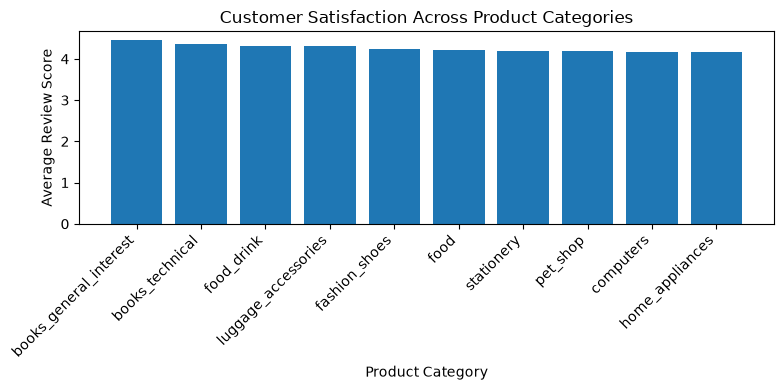

In [72]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

plt.bar(
    category_ratings["product_category_name_english"],
    category_ratings["Average_Review_Score"]
)

plt.title("Customer Satisfaction Across Product Categories")
plt.xlabel("Product Category")
plt.ylabel("Average Review Score")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

### Observation
Customer satisfaction remains consistently high across the top-rated product categories, with average review scores exceeding 4.17 out of 5. Books – General Interest received the highest average rating (4.45), followed by Books – Technical (4.37) and Food & Drink (4.32). Categories such as Stationery (2,507 reviews) and Pet Shop (1,939 reviews) also maintained strong ratings despite having a large number of customer reviews, indicating that they consistently deliver a positive customer experience at scale.

### Business Recommendation
Preserving the quality standards of these highly rated categories can help strengthen customer loyalty and encourage repeat purchases. The practices followed by top-performing categories can also be analyzed and applied to lower-rated categories to improve the overall shopping experience. Highlighting these well-rated products through recommendations and promotional campaigns may further increase customer confidence and drive additional sales.

## 10. Key Findings

• Health & Beauty emerged as the highest revenue-generating product category, making it one of the strongest contributors to overall business performance.

• Bed, Bath & Table recorded the highest number of customer orders, highlighting its strong demand and consistent purchasing activity.

• Monthly sales showed noticeable fluctuations over time, indicating the presence of seasonal purchasing patterns that can influence revenue throughout the year.

• São Paulo (SP) generated the highest revenue among all states, confirming its importance as the company's primary market.

• A small group of sellers contributed a significant share of total revenue, while most sellers generated comparatively lower sales, reflecting an uneven revenue distribution.

• Products receiving higher customer review scores generally demonstrated stronger sales performance, suggesting a positive relationship between customer satisfaction and purchasing behavior.

• Credit Card remained the most preferred payment method, accounting for the majority of transactions and generating the highest revenue among all payment options.

• Books – General Interest, Books – Technical, and Food & Drink achieved the highest average customer ratings, while categories such as Stationery and Pet Shop maintained excellent satisfaction levels despite receiving a large number of reviews.

## 11. Turning Insights into Action

• Strengthen inventory planning and promotional efforts for high-performing product categories such as Health & Beauty and Bed, Bath & Table to sustain revenue growth and meet customer demand.

• Plan marketing campaigns around seasonal sales trends to maximize revenue during peak periods while improving performance during slower months.

• Expand customer acquisition and seller partnerships in high-performing regions such as São Paulo, while identifying opportunities to improve market presence in lower-performing states.

• Encourage knowledge sharing between top-performing sellers and other sellers by adopting successful selling strategies and best practices across the marketplace.

• Continue improving product quality and customer service, as higher customer satisfaction is closely associated with stronger sales performance and long-term customer loyalty.

• Maintain a fast and reliable credit card payment experience while promoting alternative payment methods through targeted offers to provide customers with greater flexibility.

• Feature highly rated product categories in promotional campaigns and personalized product recommendations to strengthen customer trust and encourage repeat purchases.

## 12. Executive Summary

This project explored the Olist E-commerce dataset to analyze sales performance, customer purchasing behavior, seller performance, payment preferences, and customer satisfaction across different product categories. Through data cleaning, dataset integration, KPI analysis, and exploratory data analysis using Python and Pandas, several meaningful business insights were identified.

The findings revealed the product categories, regions, sellers, and payment methods that contributed most to business performance while also highlighting customer satisfaction trends across different product categories. These insights demonstrate how data-driven analysis can support better business decisions, improve customer experience, optimize operational strategies, and identify opportunities for sustainable business growth.